In [54]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import lightgbm as lgb

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

RANDOM_STATE = 42
N_TRIALS = 50

os.makedirs("results", exist_ok=True)
os.makedirs("plots", exist_ok=True)

data_path = "data/all_months_features.csv"

if not os.path.exists(data_path):
    raise FileNotFoundError(f"File not found: {data_path}")

df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Number of products: {df['Product_Name'].nunique()}")

Dataset shape: (798, 77)
Number of products: 95


In [55]:
# Create Month Index and Next-Month Targets
df = df.sort_values("Product_Name").reset_index(drop=True)
df["month_idx"] = df.groupby("Product_Name").cumcount() + 1
df = df.sort_values(["Product_Name", "month_idx"]).reset_index(drop=True)

targets_base = ["Min_Price", "Avg_Price", "Max_Price"]
targets_next = ["Min_Price_next", "Avg_Price_next", "Max_Price_next"]

for base, nxt in zip(targets_base, targets_next):
    df[nxt] = df.groupby("Product_Name")[base].shift(-1)

print(df.groupby("month_idx")["Product_Name"].nunique().to_string())

month_idx
1     95
2     91
3     90
4     89
5     85
6     83
7     80
8     71
9     64
10    50


In [56]:
# Training, Validation and Test/Forecast Split
train_df = df[df["month_idx"] <= 8].dropna(subset=targets_next).copy()
valid_df = df[df["month_idx"] == 9].dropna(subset=targets_next).copy()
test_df = df[df["month_idx"] == 10].copy()

print(f"Training   Month 1-8 : {len(train_df)}")
print(f"Validation Month 9   : {len(valid_df)}")
print(f"Test/Input Month 10  : {len(test_df)}")
print("Forecast target       : Month 11")

Training   Month 1-8 : 591
Validation Month 9   : 48
Test/Input Month 10  : 50
Forecast target       : Month 11


In [57]:
non_feature_cols = ["Product_Name", "Category", "Unit", "unit_canonical", "month_name", "bs_year", "bs_month", "month_idx"] + targets_base + targets_next
feature_cols = [c for c in df.columns if c not in non_feature_cols]

X_train = train_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y_train = train_df[targets_next]

X_valid = valid_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y_valid = valid_df[targets_next]

X_test = test_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

print(f"Number of features: {len(feature_cols)}")
print(f"X_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"X_test : {X_test.shape}")

Number of features: 66
X_train: (591, 66)
X_valid: (48, 66)
X_test : (50, 66)


In [58]:
# Helper Functions for Model Evaluation
def apply_constraint(pred):
    pred = np.asarray(pred).copy()
    pred[:, 0] = np.minimum(pred[:, 0], pred[:, 1])
    pred[:, 2] = np.maximum(pred[:, 2], pred[:, 1])
    return pred

def regression_metrics(actual, pred):
    results = []
    for i, target in enumerate(targets_next):
        a = actual.iloc[:, i].values
        p = pred[:, i]
        results.append({
            "Target": target,
            "MAE": mean_absolute_error(a, p),
            "RMSE": np.sqrt(mean_squared_error(a, p)),
            "MAPE (%)": mean_absolute_percentage_error(a, p) * 100,
            "R²": r2_score(a, p)
        })
    return pd.DataFrame(results)

print("Helper functions ready.")

Helper functions ready.


In [59]:
# Baseline Validation
baseline_valid = np.column_stack([
    X_valid["Min_Price_lag1"].values,
    X_valid["Avg_Price_lag1"].values,
    X_valid["Max_Price_lag1"].values
])

baseline_valid = apply_constraint(baseline_valid)
baseline_valid_metrics = regression_metrics(y_valid, baseline_valid)

print("BASELINE VALIDATION: MONTH 9 → MONTH 10")
print(baseline_valid_metrics.round(2).to_string(index=False))

BASELINE VALIDATION: MONTH 9 → MONTH 10
        Target    MAE   RMSE  MAPE (%)    R²
Min_Price_next  80.04 114.02     70.54 -1.18
Avg_Price_next 102.24 142.46     66.60 -0.88
Max_Price_next 124.62 178.11     63.99 -0.64


In [60]:
# Optuna Random Forest Hyperparameter Optimization
def rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    model = MultiOutputRegressor(RandomForestRegressor(**params))
    model.fit(X_train, y_train)
    pred = apply_constraint(model.predict(X_valid))

    rmse = [np.sqrt(mean_squared_error(y_valid.iloc[:, i], pred[:, i])) for i in range(3)]
    return np.mean(rmse)

rf_study = optuna.create_study(direction="minimize", study_name="RandomForest_Price_Forecasting")
rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best RF Validation RMSE:", round(rf_study.best_value, 4))
print("Best RF Parameters:")
print(rf_study.best_params)

rf_study.trials_dataframe().to_csv("results/optuna_rf_trials.csv", index=False)

[I 2026-08-16 15:59:21,114] A new study created in memory with name: RandomForest_Price_Forecasting
Best trial: 0. Best value: 56.7829:   2%|▏         | 1/50 [00:02<02:08,  2.63s/it]

[I 2026-08-16 15:59:23,752] Trial 0 finished with value: 56.78290012107099 and parameters: {'n_estimators': 350, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 1.0, 'bootstrap': True}. Best is trial 0 with value: 56.78290012107099.


Best trial: 0. Best value: 56.7829:   4%|▍         | 2/50 [00:02<01:02,  1.30s/it]

[I 2026-08-16 15:59:24,124] Trial 1 finished with value: 79.06505659312116 and parameters: {'n_estimators': 100, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 56.78290012107099.


Best trial: 0. Best value: 56.7829:   6%|▌         | 3/50 [00:06<01:47,  2.28s/it]

...

[I 2026-08-16 16:01:34,544] Trial 47 finished with value: 55.10758530098488 and parameters: {'n_estimators': 600, 'max_depth': 30, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 0.8, 'bootstrap': False}. Best is trial 47 with value: 55.10758530098488.


Best trial: 47. Best value: 55.1076:  98%|█████████▊| 49/50 [02:19<00:06,  6.15s/it]

[I 2026-08-16 16:01:40,857] Trial 48 finished with value: 55.15211187736599 and parameters: {'n_estimators': 500, 'max_depth': 24, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 0.8, 'bootstrap': False}. Best is trial 47 with value: 55.10758530098488.


Best trial: 47. Best value: 55.1076: 100%|██████████| 50/50 [02:27<00:00,  2.94s/it]

[I 2026-08-16 16:01:48,346] Trial 49 finished with value: 63.88424248916933 and parameters: {'n_estimators': 550, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 0.8, 'bootstrap': False}. Best is trial 47 with value: 55.10758530098488.
Best RF Validation RMSE: 55.1076
Best RF Parameters:
{'n_estimators': 600, 'max_depth': 30, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 0.8, 'bootstrap': False}


In [61]:
# Optuna LightGBM
def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 10, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1
    }

    model = MultiOutputRegressor(lgb.LGBMRegressor(**params))
    model.fit(X_train, y_train)
    pred = apply_constraint(model.predict(X_valid))

    rmse = [np.sqrt(mean_squared_error(y_valid.iloc[:, i], pred[:, i])) for i in range(3)]
    return np.mean(rmse)

lgb_study = optuna.create_study(direction="minimize", study_name="LightGBM_Price_Forecasting")
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best LightGBM Validation RMSE:", round(lgb_study.best_value, 4))
print("Best LightGBM Parameters:")
print(lgb_study.best_params)

lgb_study.trials_dataframe().to_csv("results/optuna_lgb_trials.csv", index=False)

[I 2026-08-16 16:02:18,653] A new study created in memory with name: LightGBM_Price_Forecasting
Best trial: 0. Best value: 74.2194:   2%|▏         | 1/50 [00:00<00:15,  3.20it/s]

[I 2026-08-16 16:02:18,969] Trial 0 finished with value: 74.21939503295313 and parameters: {'n_estimators': 150, 'learning_rate': 0.01541469848590236, 'num_leaves': 74, 'max_depth': 8, 'min_child_samples': 45, 'subsample': 0.7195990338929729, 'colsample_bytree': 0.7184181029750648, 'reg_alpha': 0.001926295314849994, 'reg_lambda': 0.006877889681694498}. Best is trial 0 with value: 74.21939503295313.


Best trial: 1. Best value: 55.7234:   4%|▍         | 2/50 [00:04<02:02,  2.55s/it]

[I 2026-08-16 16:02:23,079] Trial 1 finished with value: 55.72341721926191 and parameters: {'n_estimators': 700, 'learning_rate': 0.04030792918196725, 'num_leaves': 14, 'max_depth': 12, 'min_child_samples': 24, 'subsample': 0.6110461095574101, 'colsample_bytree': 0.9733553916369584, 'reg_alpha': 0.0008109538129127178, 'reg_lambda': 0.013560744515831395}. Best is trial 1 with value: 55.72341721926191.


Best trial: 1. Best value: 55.7234:   6%|▌         | 3/50 [00:05<01:20,  1.71s/it]

...

[I 2026-08-16 16:03:44,546] Trial 47 finished with value: 67.47764914385597 and parameters: {'n_estimators': 450, 'learning_rate': 0.06911157957424868, 'num_leaves': 18, 'max_depth': 5, 'min_child_samples': 50, 'subsample': 0.990572786169222, 'colsample_bytree': 0.8612198812255387, 'reg_alpha': 0.20439910968141173, 'reg_lambda': 2.368655884690241e-06}. Best is trial 41 with value: 50.95483644931803.


Best trial: 41. Best value: 50.9548:  98%|█████████▊| 49/50 [01:27<00:01,  1.13s/it]

[I 2026-08-16 16:03:45,702] Trial 48 finished with value: 59.310675553807236 and parameters: {'n_estimators': 600, 'learning_rate': 0.010016006454764803, 'num_leaves': 12, 'max_depth': 4, 'min_child_samples': 11, 'subsample': 0.9196290797222588, 'colsample_bytree': 0.7265435051935232, 'reg_alpha': 0.8810971980681906, 'reg_lambda': 0.007360572016901442}. Best is trial 41 with value: 50.95483644931803.


Best trial: 41. Best value: 50.9548: 100%|██████████| 50/50 [01:29<00:00,  1.79s/it]

[I 2026-08-16 16:03:48,163] Trial 49 finished with value: 52.710320002248885 and parameters: {'n_estimators': 500, 'learning_rate': 0.016897875915542992, 'num_leaves': 24, 'max_depth': 6, 'min_child_samples': 7, 'subsample': 0.9448178167260047, 'colsample_bytree': 0.8331429745600515, 'reg_alpha': 2.183324895545651, 'reg_lambda': 4.188638854874868}. Best is trial 41 with value: 50.95483644931803.
Best LightGBM Validation RMSE: 50.9548
Best LightGBM Parameters:
{'n_estimators': 450, 'learning_rate': 0.03612148855493179, 'num_leaves': 23, 'max_depth': 3, 'min_child_samples': 7, 'subsample': 0.9521587574481721, 'colsample_bytree': 0.826115578846076, 'reg_alpha': 2.3859436594553496, 'reg_lambda': 0.43052346656699203}


In [62]:
# Validation with Optimized Models
rf_params = rf_study.best_params.copy()
rf_params.update({"random_state": RANDOM_STATE, "n_jobs": -1})

rf_valid_model = MultiOutputRegressor(RandomForestRegressor(**rf_params))
rf_valid_model.fit(X_train, y_train)
rf_valid_pred = apply_constraint(rf_valid_model.predict(X_valid))

lgb_params = lgb_study.best_params.copy()
lgb_params.update({"random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": -1})

lgb_valid_model = MultiOutputRegressor(lgb.LGBMRegressor(**lgb_params))
lgb_valid_model.fit(X_train, y_train)
lgb_valid_pred = apply_constraint(lgb_valid_model.predict(X_valid))

rf_valid_metrics = regression_metrics(y_valid, rf_valid_pred)
lgb_valid_metrics = regression_metrics(y_valid, lgb_valid_pred)

print("RANDOM FOREST VALIDATION")
print(rf_valid_metrics.round(2).to_string(index=False))

print("\nLIGHTGBM VALIDATION")
print(lgb_valid_metrics.round(2).to_string(index=False))

RANDOM FOREST VALIDATION
        Target   MAE  RMSE  MAPE (%)   R²
Min_Price_next 40.14 56.58     50.05 0.46
Avg_Price_next 38.33 49.40     31.40 0.77
Max_Price_next 39.18 59.35     23.86 0.82

LIGHTGBM VALIDATION
        Target   MAE  RMSE  MAPE (%)   R²
Min_Price_next 35.83 50.42     39.45 0.57
Avg_Price_next 36.53 47.88     28.45 0.79
Max_Price_next 39.67 54.57     23.69 0.85


In [63]:
# Baseline vs Random Forest vs LightGBM
comparison = []

for i, target in enumerate(targets_next):
    actual = y_valid.iloc[:, i]
    base = baseline_valid[:, i]
    rf = rf_valid_pred[:, i]
    lgbm = lgb_valid_pred[:, i]

    base_mae = mean_absolute_error(actual, base)
    rf_mae = mean_absolute_error(actual, rf)
    lgb_mae = mean_absolute_error(actual, lgbm)

    comparison.append({
        "Target": target,
        "Baseline MAE": base_mae,
        "RF MAE": rf_mae,
        "LightGBM MAE": lgb_mae,
        "Baseline RMSE": np.sqrt(mean_squared_error(actual, base)),
        "RF RMSE": np.sqrt(mean_squared_error(actual, rf)),
        "LightGBM RMSE": np.sqrt(mean_squared_error(actual, lgbm)),
        "Baseline MAPE (%)": mean_absolute_percentage_error(actual, base) * 100,
        "RF MAPE (%)": mean_absolute_percentage_error(actual, rf) * 100,
        "LightGBM MAPE (%)": mean_absolute_percentage_error(actual, lgbm) * 100,
        "Baseline R²": r2_score(actual, base),
        "RF R²": r2_score(actual, rf),
        "LightGBM R²": r2_score(actual, lgbm),
        "RF Improvement (%)": ((base_mae - rf_mae) / base_mae) * 100,
        "LightGBM Improvement (%)": ((base_mae - lgb_mae) / base_mae) * 100
    })

comparison_df = pd.DataFrame(comparison).round(2)

print("MODEL COMPARISON: MONTH 9 → MONTH 10")
print(comparison_df.to_string(index=False))

comparison_df.to_csv("results/model_comparison_validation.csv", index=False)

MODEL COMPARISON: MONTH 9 → MONTH 10
        Target  Baseline MAE  RF MAE  LightGBM MAE  Baseline RMSE  RF RMSE  LightGBM RMSE  Baseline MAPE (%)  RF MAPE (%)  LightGBM MAPE (%)  Baseline R²  RF R²  LightGBM R²  RF Improvement (%)  LightGBM Improvement (%)
Min_Price_next         80.04   40.14         35.83         114.02    56.58          50.42              70.54        50.05              39.45        -1.18   0.46         0.57               49.86                     55.24
Avg_Price_next        102.24   38.33         36.53         142.46    49.40          47.88              66.60        31.40              28.45        -0.88   0.77         0.79               62.50                     64.27
Max_Price_next        124.62   39.18         39.67         178.11    59.35          54.57              63.99        23.86              23.69        -0.64   0.82         0.85               68.56                     68.17


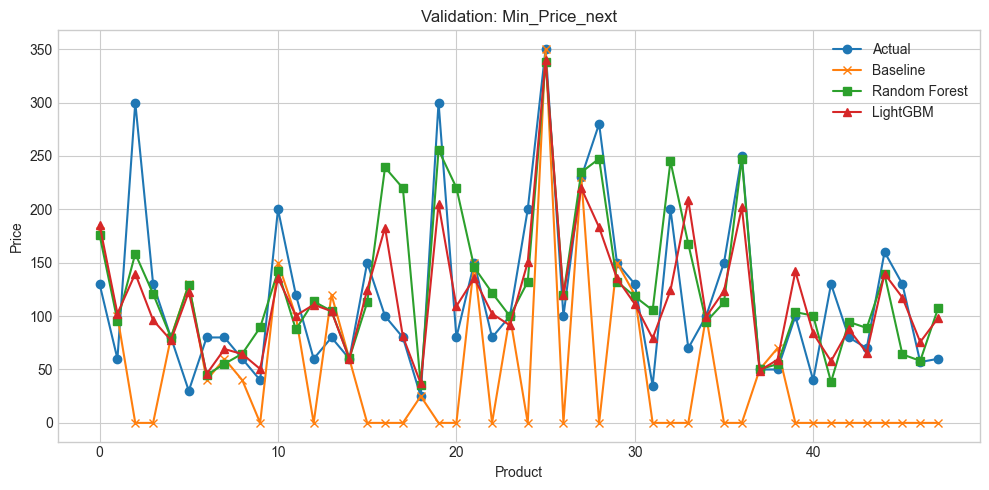

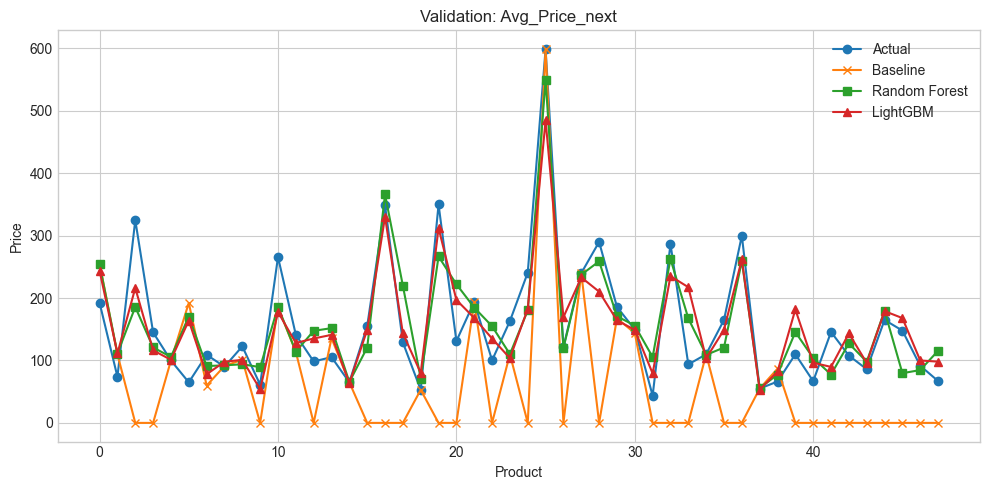

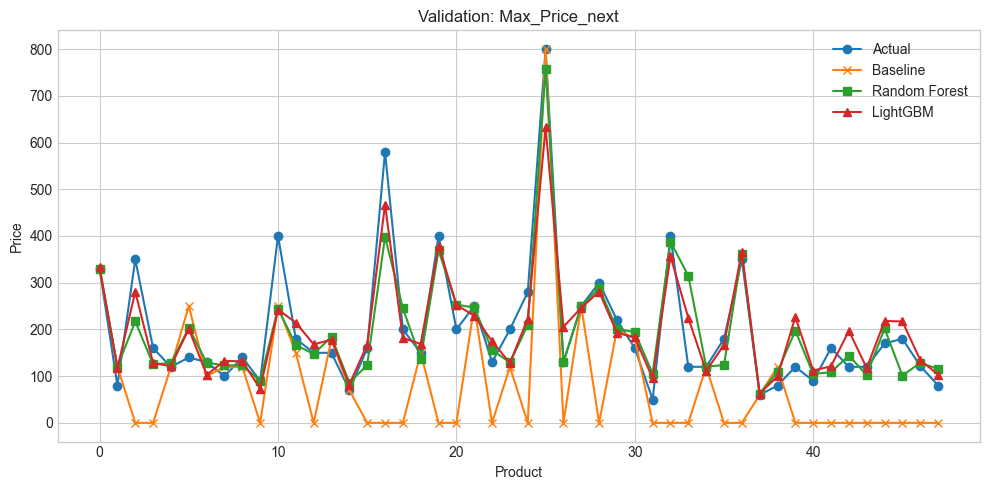

In [66]:
# Actual vs Predicted 
for i, target in enumerate(targets_next):
    plt.figure(figsize=(10, 5))
    plt.plot(y_valid.iloc[:, i].values, marker="o", label="Actual")
    plt.plot(baseline_valid[:, i], marker="x", label="Baseline")
    plt.plot(rf_valid_pred[:, i], marker="s", label="Random Forest")
    plt.plot(lgb_valid_pred[:, i], marker="^", label="LightGBM")
    plt.title(f"Validation: {target}")
    plt.xlabel("Product")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/{target}_validation_prediction.png", dpi=300, bbox_inches="tight")
    plt.show()

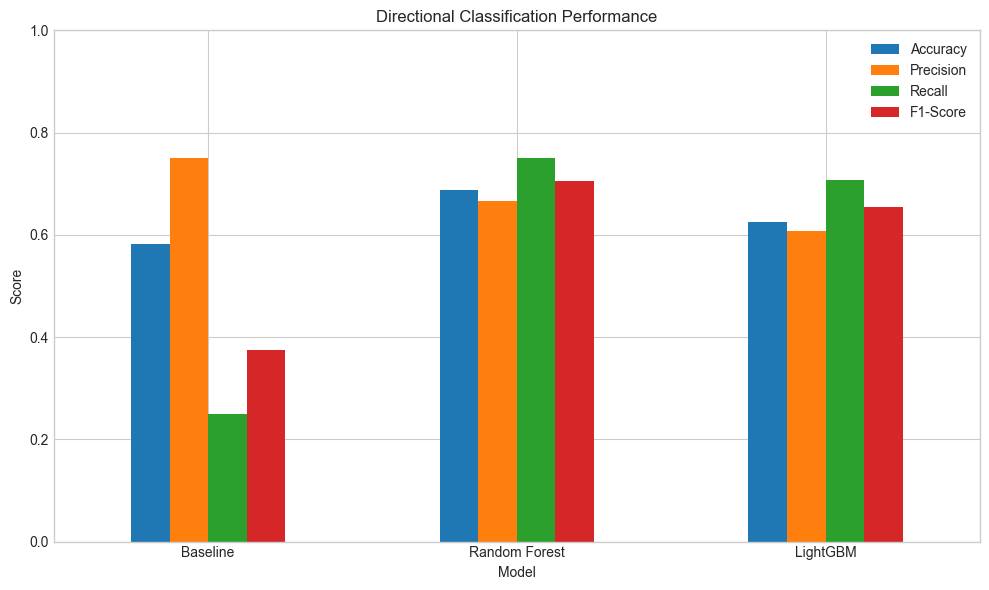

In [72]:
# Directional Performance Visualization
ax = direction_df.set_index("Model").plot(kind="bar", figsize=(10, 6))
ax.set_title("Directional Classification Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plots/directional_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [73]:
# Ordering Violations Check
for name, pred in [("Baseline", baseline_valid), ("Random Forest", rf_valid_pred), ("LightGBM", lgb_valid_pred)]:
    violations = (pred[:, 0] > pred[:, 1]) | (pred[:, 1] > pred[:, 2])
    print(f"{name}: {violations.sum()} violations ({violations.mean() * 100:.2f}%)")

Baseline: 0 violations (0.00%)
Random Forest: 0 violations (0.00%)
LightGBM: 0 violations (0.00%)


In [74]:
#Final Training Using Month 1–9
train_final = pd.concat([train_df, valid_df], ignore_index=True)

X_train_final = train_final[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y_train_final = train_final[targets_next]

rf_final = MultiOutputRegressor(RandomForestRegressor(**rf_params))
rf_final.fit(X_train_final, y_train_final)

lgb_final = MultiOutputRegressor(lgb.LGBMRegressor(**lgb_params))
lgb_final.fit(X_train_final, y_train_final)

rf_month11 = apply_constraint(rf_final.predict(X_test))
lgb_month11 = apply_constraint(lgb_final.predict(X_test))

baseline_month11 = np.column_stack([
    X_test["Min_Price_lag1"].values,
    X_test["Avg_Price_lag1"].values,
    X_test["Max_Price_lag1"].values
])

baseline_month11 = apply_constraint(baseline_month11)

print(f"Final training rows: {len(train_final)}")
print(f"Month 10 forecasting rows: {len(test_df)}")
print("Month 11 forecasts generated.") 

Final training rows: 639
Month 10 forecasting rows: 50
Month 11 forecasts generated.


In [75]:
# Month 11 Forecast Table
forecast_df = test_df[["Product_Name", "month_idx"]].copy().reset_index(drop=True)
forecast_df["Forecast_Month"] = 11

forecast_df["Baseline_Min_Price"] = baseline_month11[:, 0]
forecast_df["Baseline_Avg_Price"] = baseline_month11[:, 1]
forecast_df["Baseline_Max_Price"] = baseline_month11[:, 2]

forecast_df["RF_Predicted_Min_Price"] = rf_month11[:, 0]
forecast_df["RF_Predicted_Avg_Price"] = rf_month11[:, 1]
forecast_df["RF_Predicted_Max_Price"] = rf_month11[:, 2]

forecast_df["LightGBM_Predicted_Min_Price"] = lgb_month11[:, 0]
forecast_df["LightGBM_Predicted_Avg_Price"] = lgb_month11[:, 1]
forecast_df["LightGBM_Predicted_Max_Price"] = lgb_month11[:, 2]

forecast_df = forecast_df.round(2)

print(forecast_df.head(10).to_string(index=False))

      Product_Name  month_idx  Forecast_Month  Baseline_Min_Price  Baseline_Avg_Price  Baseline_Max_Price  RF_Predicted_Min_Price  RF_Predicted_Avg_Price  RF_Predicted_Max_Price  LightGBM_Predicted_Min_Price  LightGBM_Predicted_Avg_Price  LightGBM_Predicted_Max_Price
             Apple         10              11                 0.0                0.00                 0.0                  240.66                  335.34                  489.30                        245.34                        376.20                        490.17
              Arum         10              11                60.0               65.26                80.0                   65.34                   69.84                   84.58                         56.88                         69.65                         86.03
           Avocado         10              11               300.0              325.00               350.0                  307.98                  466.77                  549.50                   

In [76]:
# Save Month 11 Forecast
forecast_df.to_csv("results/month_11_forecasts.csv", index=False)
print("Saved: results/month_11_forecasts.csv")

Saved: results/month_11_forecasts.csv


Feature
price_spread_ratio      291.333333
price_spread            271.333333
Avg_Price_lag1          200.333333
Min_Price_roll3_mean    147.666667
n_months_present        122.666667
Volume                  121.000000
volume_change_ratio     109.333333
Total_Amount             83.333333
Avg_Price_roll3_mean     82.333333
Max_Price_roll3_mean     81.333333
Min_Price_lag1           80.000000
Max_Price_lag1           65.000000
Avg_Price_roll3_std      65.000000
Sunsari                  62.000000
ktm_supply_share         54.666667
Local                    50.666667
Min_Price_roll3_std      46.666667
Max_Price_roll3_std      46.000000
cos_month                45.000000
China                    39.666667
Name: Importance, dtype: float64


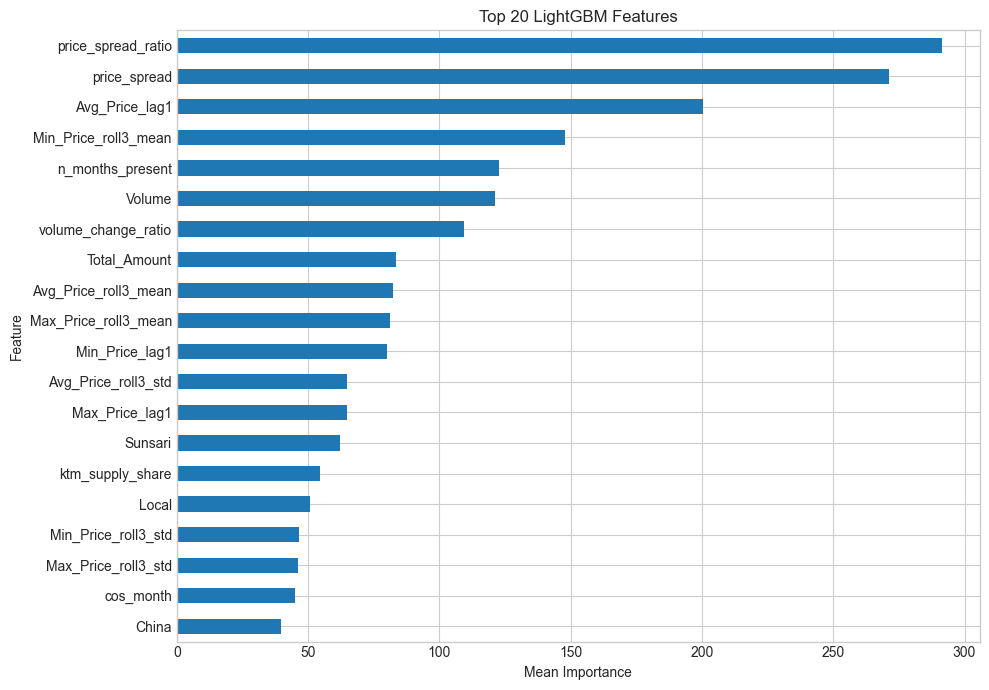

In [78]:
# LightGBM Feature Importance
importance_list = []

for i, model in enumerate(lgb_final.estimators_):
    importance_list.append(pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_,
        "Target": targets_next[i]
    }))

feature_importance = pd.concat(importance_list, ignore_index=True)
mean_importance = feature_importance.groupby("Feature")["Importance"].mean().sort_values(ascending=False)

print(mean_importance.head(20))

plt.figure(figsize=(10, 7))
mean_importance.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 LightGBM Features")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.savefig("plots/lightgbm_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

feature_importance.to_csv("results/lightgbm_feature_importance.csv", index=False)

In [79]:
validation_results = valid_df[["Product_Name", "month_idx"]].reset_index(drop=True)

for i, target in enumerate(targets_next):
    validation_results[f"Actual_{target}"] = y_valid.iloc[:, i].values
    validation_results[f"Baseline_{target}"] = baseline_valid[:, i]
    validation_results[f"RF_{target}"] = rf_valid_pred[:, i]
    validation_results[f"LightGBM_{target}"] = lgb_valid_pred[:, i]

validation_results.round(2).to_csv("results/validation_month_9_predictions.csv", index=False)

print("Saved: results/validation_month_9_predictions.csv")

Saved: results/validation_month_9_predictions.csv


In [80]:
print("FINAL SUMMARY")
print("Training       : Month 1-8")
print("Validation     : Month 9 → Month 10")
print("Final Training : Month 1-9")
print("Forecast Input : Month 10")
print("Forecast       : Month 11")

print(f"\nRF Best Validation RMSE      : {rf_study.best_value:.3f}")
print(f"LightGBM Best Validation RMSE: {lgb_study.best_value:.3f}")

print(f"\nRF Mean Validation MAE       : {rf_valid_metrics['MAE'].mean():.2f}")
print(f"LightGBM Mean Validation MAE : {lgb_valid_metrics['MAE'].mean():.2f}")

print(f"RF Mean Validation R²        : {rf_valid_metrics['R²'].mean():.3f}")
print(f"LightGBM Mean Validation R²  : {lgb_valid_metrics['R²'].mean():.3f}")

print("\nFiles saved in:")
print("results/")
print("plots/")
print("\n✓ COMPLETE PRICE FORECASTING PIPELINE FINISHED")

FINAL SUMMARY
Training       : Month 1-8
Validation     : Month 9 → Month 10
Final Training : Month 1-9
Forecast Input : Month 10
Forecast       : Month 11

RF Best Validation RMSE      : 55.108
LightGBM Best Validation RMSE: 50.955

RF Mean Validation MAE       : 39.22
LightGBM Mean Validation MAE : 37.34
RF Mean Validation R²        : 0.685
LightGBM Mean Validation R²  : 0.735

Files saved in:
results/
plots/

✓ COMPLETE PRICE FORECASTING PIPELINE FINISHED


In [81]:
# Category-wise error analysis
category_results = []

for category in valid_df["Category"].unique():
    mask = valid_df["Category"] == category

    for i, target in enumerate(targets_next):
        actual = y_valid.loc[mask, target].values
        rf_pred = rf_valid_pred[mask.values, i]
        lgb_pred = lgb_valid_pred[mask.values, i]

        category_results.append({
            "Category": category,
            "Target": target,
            "RF MAE": mean_absolute_error(actual, rf_pred),
            "LightGBM MAE": mean_absolute_error(actual, lgb_pred)
        })

category_error_df = pd.DataFrame(category_results).round(2)

print("CATEGORY-WISE MAE")
print(category_error_df.to_string(index=False))

category_error_df.to_csv("results/category_wise_error.csv", index=False)

CATEGORY-WISE MAE
 Category         Target  RF MAE  LightGBM MAE
    fruit Min_Price_next   34.89         49.17
    fruit Avg_Price_next   43.93         48.08
    fruit Max_Price_next   43.18         42.83
vegetable Min_Price_next   42.76         29.16
vegetable Avg_Price_next   35.54         30.75
vegetable Max_Price_next   37.18         38.10


In [83]:
unit_results = []

for unit in valid_df["Unit"].unique():
    mask = valid_df["Unit"] == unit

    for i, target in enumerate(targets_next):
        actual = y_valid.loc[mask, target].values
        rf_pred = rf_valid_pred[mask.values, i]
        lgb_pred = lgb_valid_pred[mask.values, i]

        unit_results.append({
            "Unit": unit,
            "Target": target,
            "RF MAE": mean_absolute_error(actual, rf_pred),
            "LightGBM MAE": mean_absolute_error(actual, lgb_pred),
            "Samples": mask.sum()
        })

unit_error_df = pd.DataFrame(unit_results).round(2)

print("UNIT-WISE MAE")
print(unit_error_df.to_string(index=False))

unit_error_df.to_csv("results/unit_wise_error.csv", index=False)

UNIT-WISE MAE
 Unit         Target  RF MAE  LightGBM MAE  Samples
   kg Min_Price_next   42.74         36.96       42
   kg Avg_Price_next   40.35         38.00       42
   kg Max_Price_next   41.07         40.19       42
dozen Min_Price_next    9.12         33.81        1
dozen Avg_Price_next   24.12         28.74        1
dozen Max_Price_next   34.56         32.03        1
mutha Min_Price_next   21.42         29.37        3
mutha Avg_Price_next   24.13         36.26        3
mutha Max_Price_next   17.67         42.92        3
  nos Min_Price_next   29.07         22.84        2
  nos Avg_Price_next   24.43         10.00        2
  nos Max_Price_next   34.15         27.78        2


In [84]:
# Volatile Products Analysis
volatility_df = df.copy()
volatility_df["Price_Spread"] = volatility_df["Max_Price"] - volatility_df["Min_Price"]

product_volatility = volatility_df.groupby("Product_Name").agg(
    Mean_Price_Spread=("Price_Spread", "mean"),
    Price_Spread_STD=("Price_Spread", "std"),
    Months=("month_idx", "count")
).reset_index()

product_volatility = product_volatility.sort_values("Mean_Price_Spread", ascending=False)

print("TOP 15 MOST VOLATILE PRODUCTS")
print(product_volatility.head(15).round(2).to_string(index=False))

product_volatility.to_csv("results/product_volatility.csv", index=False)

TOP 15 MOST VOLATILE PRODUCTS
    Product_Name  Mean_Price_Spread  Price_Spread_STD  Months
  Akabary_Chilly             320.00            216.79       5
 Coriander_Green             305.40            186.59      10
     Cabbage_Red             204.00            127.03      10
            Kiwi             160.00            171.27      10
      Red_Grapes             160.00             65.90       8
    Garlic_Green             152.00            117.36      10
         Avocado             150.00            209.50      10
           Apple             149.00             39.71      10
     Onion_Green             123.00             66.17      10
Khasa_Garlic_Dry             107.00             90.56      10
     French_Bean             102.00             22.01      10
          Kurilo             100.00              0.00       8
        Broccoli              98.89             64.89       9
         Cow_Pea              97.00             41.11      10
          Orange              96.67     

In [85]:
# Volatile Products Forecast Error Analysis
product_error_results = []

for product in valid_df["Product_Name"].unique():
    mask = valid_df["Product_Name"] == product

    rf_maes = []
    lgb_maes = []

    for i, target in enumerate(targets_next):
        actual = y_valid.loc[mask, target].values
        rf_pred = rf_valid_pred[mask.values, i]
        lgb_pred = lgb_valid_pred[mask.values, i]

        rf_maes.append(mean_absolute_error(actual, rf_pred))
        lgb_maes.append(mean_absolute_error(actual, lgb_pred))

    product_error_results.append({
        "Product_Name": product,
        "RF_Mean_MAE": np.mean(rf_maes),
        "LightGBM_Mean_MAE": np.mean(lgb_maes)
    })

product_error_df = pd.DataFrame(product_error_results)

volatile_analysis = product_volatility.merge(product_error_df, on="Product_Name", how="left")

print("MOST VOLATILE PRODUCTS WITH FORECAST ERRORS")
print(volatile_analysis.head(15).round(2).to_string(index=False))

volatile_analysis.to_csv("results/volatile_product_analysis.csv", index=False)

MOST VOLATILE PRODUCTS WITH FORECAST ERRORS
    Product_Name  Mean_Price_Spread  Price_Spread_STD  Months  RF_Mean_MAE  LightGBM_Mean_MAE
  Akabary_Chilly             320.00            216.79       5          NaN                NaN
 Coriander_Green             305.40            186.59      10       112.83              71.37
     Cabbage_Red             204.00            127.03      10        97.61             103.33
            Kiwi             160.00            171.27      10        34.36              97.09
      Red_Grapes             160.00             65.90       8          NaN                NaN
    Garlic_Green             152.00            117.36      10         5.52              20.36
         Avocado             150.00            209.50      10       137.87             112.74
           Apple             149.00             39.71      10        35.90              36.82
     Onion_Green             123.00             66.17      10        27.13              57.02
Khasa_Garlic_Dry

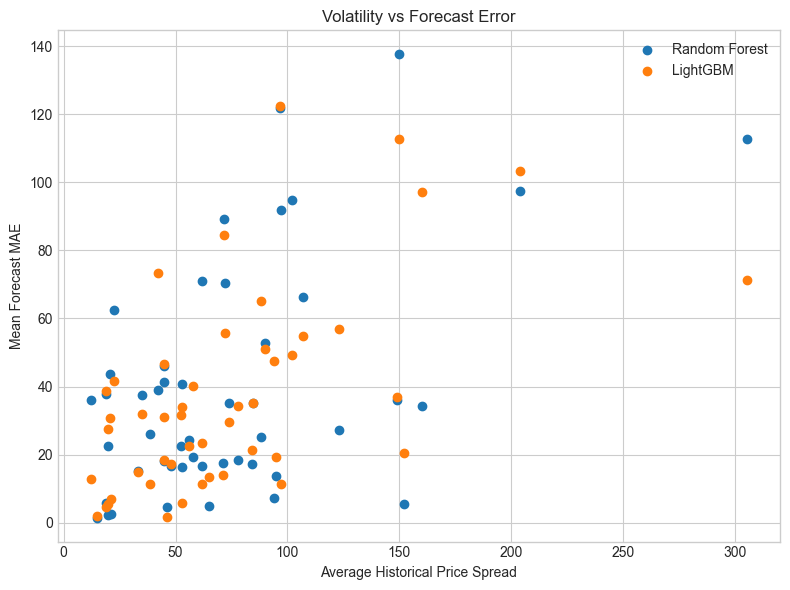

In [86]:
plt.figure(figsize=(8, 6))
plt.scatter(volatile_analysis["Mean_Price_Spread"], volatile_analysis["RF_Mean_MAE"], label="Random Forest")
plt.scatter(volatile_analysis["Mean_Price_Spread"], volatile_analysis["LightGBM_Mean_MAE"], label="LightGBM")
plt.xlabel("Average Historical Price Spread")
plt.ylabel("Mean Forecast MAE")
plt.title("Volatility vs Forecast Error")
plt.legend()
plt.tight_layout()
plt.savefig("plots/volatility_vs_forecast_error.png", dpi=300, bbox_inches="tight")
plt.show()